# Παραδείγματα αλλαγής μεγέθους με Lanczos

Το notebook παρουσιάζει δύο εικόνες ROI του ZooLake πριν και μετά την απευθείας μετατροπή τους σε μέγεθος **128 × 128 pixels**, χωρίς διατήρηση των αρχικών αναλογιών. Η αλλαγή μεγέθους γίνεται με τη μέθοδο παρεμβολής Lanczos, όπως στην υλοποίηση του αρχικού άρθρου.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

TARGET_SIZE = (128, 128)
OUTPUT_PATH = Path('lanczos_before_after_examples.png')

# Στο Kaggle όλα τα συνδεδεμένα datasets βρίσκονται μέσα στο /kaggle/input.
DATASET_ROOT = Path('/kaggle/input/datasets/tsikaripunks/zoolake-full/zooplankton_0p5x')

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Δεν βρέθηκε ο φάκελος: {DATASET_ROOT.resolve()}')

print(f'Φάκελος δεδομένων: {DATASET_ROOT.resolve()}')

Φάκελος δεδομένων: /kaggle/input/datasets/tsikaripunks/zoolake-full/zooplankton_0p5x


In [2]:
examples = [
    {
        'class_name': 'chaoborus',
        'filename': 'SPC-EAWAG-0P5X-1562231164366128-9136548561625-003549-028-406-1936-716-396.jpeg',
    },
    {
        'class_name': 'leptodora',
        'filename': 'SPC-EAWAG-0P5X-1531358653274937-3072616948810-050429-048-622-1654-288-700.jpeg',
    },
]

def find_image(filename):
    matches = list(DATASET_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'Δεν βρέθηκε η εικόνα: {filename}')
    return matches[0]

resampling = getattr(Image, 'Resampling', Image).LANCZOS

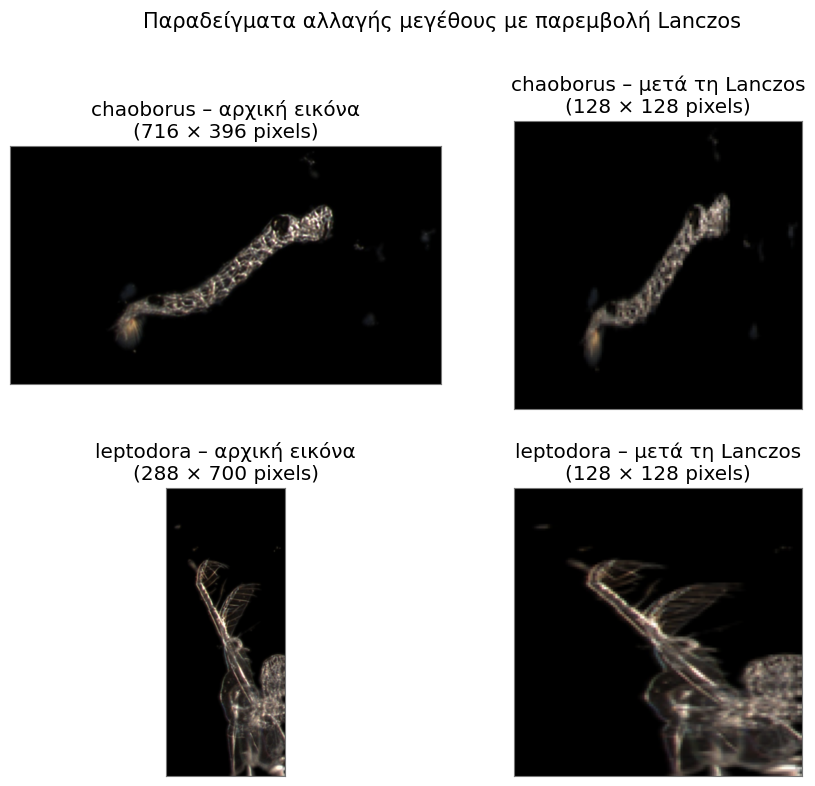

Η εικόνα αποθηκεύτηκε στο: /kaggle/working/lanczos_before_after_examples.png


In [3]:
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})
fig, axes = plt.subplots(len(examples), 2, figsize=(9, 8))

for row, example in enumerate(examples):
    image_path = find_image(example['filename'])
    with Image.open(image_path) as image:
        original = image.convert('RGB')
    resized = original.resize(TARGET_SIZE, resampling)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(
        f"{example['class_name']} – αρχική εικόνα\n"
        f"({original.width} × {original.height} pixels)"
    )

    axes[row, 1].imshow(resized)
    axes[row, 1].set_title(
        f"{example['class_name']} – μετά τη Lanczos\n"
        "(128 × 128 pixels)"
    )

    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])
        for spine in axis.spines.values():
            spine.set_color('#777777')
            spine.set_linewidth(0.8)

fig.suptitle('Παραδείγματα αλλαγής μεγέθους με παρεμβολή Lanczos', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.0, w_pad=1.2)
fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Η εικόνα αποθηκεύτηκε στο: {OUTPUT_PATH.resolve()}')

**Προτεινόμενη λεζάντα:**  
Παραδείγματα απευθείας αλλαγής μεγέθους εικόνων ROI των κατηγοριών *chaoborus* και *leptodora* σε 128 × 128 pixels με παρεμβολή Lanczos, χωρίς διατήρηση των αρχικών αναλογιών. Πηγή: ιδία επεξεργασία εικόνων από το σύνολο δεδομένων ZooLake.